## Supplementary figures & tables code

has everything except:
- SPM illustrations in `fmri_analysis/glm_scripts/vis_SPM_nilearn.ipynb` ?

In [1]:
import pandas as pd
import os.path as op
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# on the department share (assemble it first, see ../DATA_ON_SHARE.md):
# bids_folder = '/Volumes/g_econ_department$/projects/2022/renkert_dehollander_aydogan_ruff_stressrisk/data/ds-stressrisk_remaining'
bids_folder = '/Users/mrenke/data/ds-stressrisk'

# where the figures are written (outside the dataset)
supplements_path = '/Users/mrenke/Desktop/StressRisk/paper&abstracts/supplements'

sns.set_context('talk')
sns.set_theme('paper', 'white', font='helvetica', font_scale=1.5, palette='tab10')
# for bar&scatter plots to align, use env. behav_fit ! (numrefields: misaligns)


In [2]:
import arviz as az
model_label = '5' # model where priors shift together 
idata = az.from_netcdf(op.join(bids_folder, 'derivatives', 'cogmodels', f'model-{model_label}_trace.netcdf'))

In [ ]:
def get_posterior(idata,param,regressor): # adpated version (before was only idata.posterior[param] and 'subject' was and addiotnal index, but that is not what we want here!)
    df = idata.posterior[param+'_mu'].to_dataframe()
    df.index = df.index.set_names(['chain','draw','regressor'])
    df = df.xs(regressor, 0,'regressor')
    return df
    
from bauer.utils.math import softplus_np

param_list = ['risky_prior_mu','safe_prior_mu','n1_evidence_sd','n2_evidence_sd','risky_prior_std','safe_prior_std'] # 'risky_prior_std'
results_list = []

for param in param_list:
    #print(f'\n{param}')
    p_int =  get_posterior(idata,param,'Intercept')
    param_name = param
    if 'prior_mu' in param: # for risky- & safe- prior_mus, any effect can only be mediated by a general 
        param = 'prior_mu'
    p_g0_s1 = p_int
    p_g0_s2 = p_int.values  + get_posterior(idata,param,'session')
    p_g1_s1 = p_int.values  + get_posterior(idata,param,'group')
    p_g1_s2 = p_int.values  + get_posterior(idata,param,'group') + get_posterior(idata,param,'session') + get_posterior(idata,param,'session:group')
        
    results = {'Group 0, Session 1': p_g0_s1, 'Group 0, Session 2': p_g0_s2,
        'Group 1, Session 1': p_g1_s1,'Group 1, Session 2': p_g1_s2}
    for key, values in results.items():
        values = softplus_np(values.values) if ('sd' in param or 'std' in param) else values.values
        ci = np.percentile(values, [2.5, 97.5])
        #print(f'{key}: Mean = {np.mean(values.values):.3f}, 95% CI = [{ci[0]:.3f}, {ci[1]:.3f}]')
        results_list.append([param_name, key, np.mean(values), ci[0], ci[1]])
df_results = pd.DataFrame(results_list, columns=['Parameter', 'Group/Session', 'Mean', 'CI Lower', 'CI Upper'])
df_results.set_index(['Parameter', 'Group/Session'])

Mean  CI Lower  CI Upper
Parameter       Group/Session                                   
risky_prior_mu  Group 0, Session 1  3.291343  2.993922  3.577278
                Group 0, Session 2  3.171644  2.945387  3.391746
                Group 1, Session 1  2.771165  2.411254  3.147748
                Group 1, Session 2  3.158895  2.803672  3.500723
safe_prior_mu   Group 0, Session 1  3.201961  2.713737  3.776340
                Group 0, Session 2  3.082262  2.638719  3.632946
                Group 1, Session 1  2.681782  2.116092  3.292029
                Group 1, Session 2  3.069513  2.526623  3.686832
n1_evidence_sd  Group 0, Session 1  0.283917  0.229173  0.349889
                Group 0, Session 2  0.252987  0.222020  0.287219
                Group 1, Session 1  0.298745  0.229232  0.381224
                Group 1, Session 2  0.283775  0.243687  0.328330
n2_evidence_sd  Group 0, Session 1  0.198643  0.161072  0.244184
                Group 0, Session 2  0.192698  0.168315  0.218998
                Group 1, Session 1  0.215563  0.167006  0.273226
                Group 1, Session 2  0.204021  0.172681  0.236092
risky_prior_std Group 0, Session 1  0.344085  0.239295  0.474368
                Group 0, Session 2  0.367670  0.278464  0.475519
                Group 1, Session 1  0.367770  0.245238  0.520930
                Group 1, Session 2  0.367460  0.269576  0.490742
safe_prior_std  Group 0, Session 1  0.415288  0.242060  0.664322
                Group 0, Session 2  0.601553  0.392841  0.886696
                Group 1, Session 1  0.523857  0.274750  0.859193
                Group 1, Session 2  0.678107  0.423307  1.051189

In [14]:
def get_posterior(idata,param,regressor): # adpated version (before was only idata.posterior[param] and 'subject' was and addiotnal index, but that is not what we want here!)
    df = idata.posterior[param+'_mu'].to_dataframe()
    df.index = df.index.set_names(['chain','draw','regressor'])
    df = df.xs(regressor, 0,'regressor')
    df['regressor'] = regressor
    return df

results_list = []
for param in ['risky_prior_std','safe_prior_std']:
    for regressor in ['session', 'session:group']:
        dif = get_posterior(idata,param,regressor).drop('regressor', axis=1).values
        ci_lower, ci_upper = np.percentile(dif, [2.5, 97.5])
        results_list.append([param, regressor, np.round(np.mean(dif>0),3), np.mean(dif), ci_lower, ci_upper])
        #print(f'{param} - {regressor}:  p={np.mean(dif>0):.3f}, mean={np.mean(dif):.3f}, 95%CI=[{ci_lower:.3f}, {ci_upper:.3f}]')

df_results = pd.DataFrame(results_list, columns=['Parameter', 'Regressor', 'P-val', 'Mean', 'CI Lower', 'CI Upper'])
df_results.set_index(['Parameter', 'Regressor']) # print(df_results.to_string(index=False))

P-val      Mean  CI Lower  CI Upper
Parameter       Regressor                                         
risky_prior_std session        0.768  0.084970 -0.137659  0.314362
                session:group  0.314 -0.079264 -0.395347  0.253085
safe_prior_std  session        0.996  0.482564  0.118309  0.936636
                session:group  0.337 -0.125639 -0.734145  0.479683

### Model comparison

In [3]:
model_5 = idata # model 5
model_5_noStress = az.from_netcdf(op.join(bids_folder, 'derivatives', 'cogmodels', f'model-5_noStress_trace.netcdf'))
#model_PMC_noRegressors = az.from_netcdf(op.join(bids_folder, 'derivatives', 'cogmodels', f'model-1_null_trace.netcdf'))

model_EU = az.from_netcdf(op.join(bids_folder, 'derivatives', 'cogmodels', f'model-EU_3_trace.netcdf'))
model_EU_noRegressors = az.from_netcdf(op.join(bids_folder, 'derivatives', 'cogmodels', f'model-EU_noStress__trace.netcdf'))

In [4]:
compare_dict = {"PMC model": model_5, "PMC model no Stress": model_5_noStress, 
                #"model PMC no Regressors": model_PMC_noRegressors,
                "Expected utility model": model_EU, "Expected utility model no Stress": model_EU_noRegressors}
comparison = az.compare(compare_dict)
comparison
# from risk_experiment/risk_experiment/cogmodels/notebooks/compare...


/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/arviz/stats/stats.py:803: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.7 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/arviz/stats/stats.py:803: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.7 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/Users/mrenke/mambaforge/envs/

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
PMC model,0,-6083.570202,290.725246,0.000000,9.988127e-01,53.700917,0.000000,True,log
PMC model no Stress,1,-6144.865216,259.687880,61.295014,8.895528e-13,53.525108,10.214237,False,log
Expected utility model,2,-6871.064534,189.813179,787.494332,3.869097e-13,49.688854,37.831196,True,log
Expected utility model no Stress,3,-6872.946300,191.096431,789.376098,1.187282e-03,50.087274,38.192627,True,log


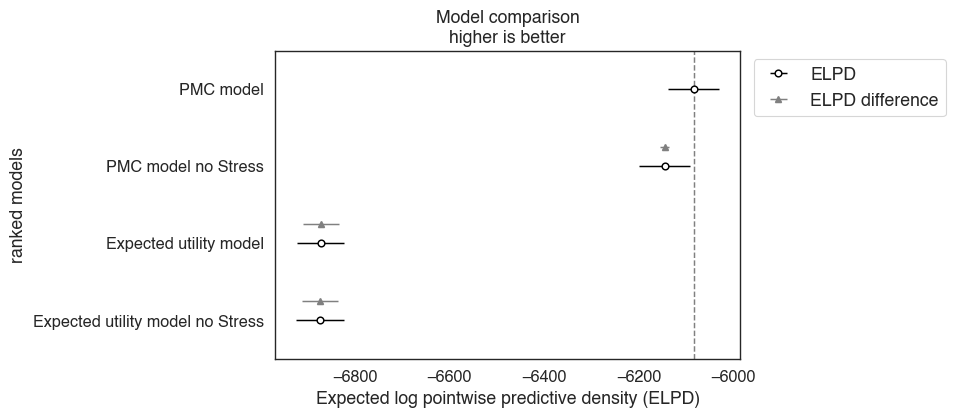

In [10]:
az.plot_compare(comparison)
import matplotlib.pyplot as plt
plt.xlabel('Expected log pointwise predictive density (ELPD)')
plt.savefig(op.join(supplements_path, 'model_comparison_all.png'), dpi=300, bbox_inches='tight')

## Stress manipulation effect plots

In [54]:
from stress_risk.analyse_results.utils import get_stress_level
df_auc = get_stress_level(bids_folder).rename(mapper={'AUC':'cortisol_auc'}, axis=1).rename(mapper={'AUC':'cortisol_auc'}, axis=1)
df_stress_sr = pd.read_csv(op.join(bids_folder, 'addMeasures', 'selfRated_Stress.csv')).rename(mapper={'mean_stress':'self-rated_auc'}, axis=1).set_index('subject')

df_comb = df_auc.join(df_stress_sr)#.set_index('group', append=True)
df_comb['group'] = df_comb['group'].astype(int)
df_comb['group'] = np.where(df_comb['group'] == 0, 'Control', 'Stress')
df_comb = df_comb.set_index('group',append=True)
df_comb.head()


,,cortisol_auc,self-rated_auc
subject,group,,
1,Control,2.060,6.981949
2,Control,-0.505,2.843103
3,Stress,3.530,7.110147
4,Stress,1.055,7.074323
5,Control,-0.635,2.557188


cortisol_auc: t=-5.349, p=0.000003
self-rated_auc: t=-4.550, p=0.000038


/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/seaborn/categorical.py:3370: UserWarning: 8.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/seaborn/categorical.py:3370: UserWarning: 8.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


Text(0, 25, 'Psychological stress level')

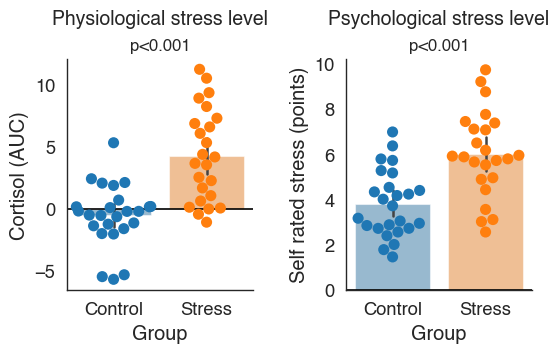

In [ ]:
from scipy.stats import ttest_ind

col_names = ['cortisol_auc', 'self-rated_auc']

fig, axs = plt.subplots(1, 2, figsize=(6,3))
for ax, column in zip(axs, col_names):
    sns.barplot(ax=ax, data=df_comb.reset_index(), x='group', y=column, hue='group',alpha=0.5, legend=False)
    sns.swarmplot(ax=ax, data=df_comb.reset_index(), x='group', y=column,  hue='group',size=8, legend=False)
    ax.axhline(0, c='black')
    t_stat, p_val = ttest_ind(df_comb.xs('Control',0,'group')[column], df_comb.xs('Stress',0,'group')[column])
    print(f'{column}: t={t_stat:.3f}, p={p_val:.6f}, ')
    #ax.set_title(f'\n p<{np.round(p_val,4)}') # {column} 
    ax.set_title(f'p<0.001', fontsize=12)

sns.despine()
fig.subplots_adjust(wspace=0.5)
axs[0].set(ylabel='Cortisol (AUC)', xlabel='Group')
axs[1].set(ylabel='Self rated stress (points)', xlabel='Group')
axs[0].annotate('Physiological stress level', xy=(0.5, 1), xytext=(0, 25),  xycoords='axes fraction', textcoords='offset points',size=14, ha='center', va='baseline',fontweight='bold')
axs[1].annotate('Psychological stress level', xy=(0.5, 1), xytext=(0, 25),  xycoords='axes fraction', textcoords='offset points',size=14, ha='center', va='baseline',fontweight='bold')

### HRV measures


In [2]:
# HRV measures

var = 'v1'
sampling_rate = 500
df = pd.read_csv(op.join(bids_folder,'interim_sum_data', f'HRV_var-{var}_sampRate-{sampling_rate}_subwise.csv')).drop('Unnamed: 0', axis=1) # withour cleaning DF-name without 'sampRate'
group_list = pd.read_csv(op.join(bids_folder, 'group_assignmentList.csv'))[['subject', 'group']].set_index('subject')   

df['subject'] = df['subject'].astype(int)
df = df.set_index(['subject','session','run']).join(group_list, on='subject').rename(mapper={'group':'Group'}, axis=1).set_index('Group', append=True)   
df.head()

HRV_LFHF   HR_meanNN  HR_bpm    HRV_SDNN  \
subject session run Group                                             
12      1       1   0      0.668331  835.010101    71.9  180.858003   
                2   0      0.704098  871.611479    68.8  188.297423   
                3   0      0.928199  844.902386    71.0  126.731766   
                4   0      0.931359  873.064877    68.7  246.049054   
                5   0      0.683022  854.413187    70.2  251.349215   

                            HRV_RMSSD  
subject session run Group              
12      1       1   0      239.364323  
                2   0      258.751666  
                3   0      154.622823  
                4   0      336.132901  
                5   0      344.307784

In [4]:
from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu
from scipy.stats import normaltest # from scipy.stats import shapiro # same results for shapiro test! 
alpha = 0.05 # threshold for normality

varlist = ['HR_bpm', 'HRV_SDNN', 'HRV_RMSSD', 'HRV_LFHF']
name_list = ['Heart rate', 'SDNN', 'RMSSD', 'LF/HF']
unit_list = ['bpm', 'ms', 'ms', 'power ratio']

HR_bpm - normal distribution (fail to reject H0)
Ttest_indResult(statistic=-0.42988683802949973, pvalue=0.6692091466050307)
HRV_SDNN - not normal distribution (reject H0)
MannwhitneyuResult(statistic=424.0, pvalue=0.03126242312068113)
HRV_RMSSD - not normal distribution (reject H0)
MannwhitneyuResult(statistic=438.0, pvalue=0.01529337103019893)
HRV_LFHF - not normal distribution (reject H0)
MannwhitneyuResult(statistic=262.0, pvalue=0.33197546708273695)


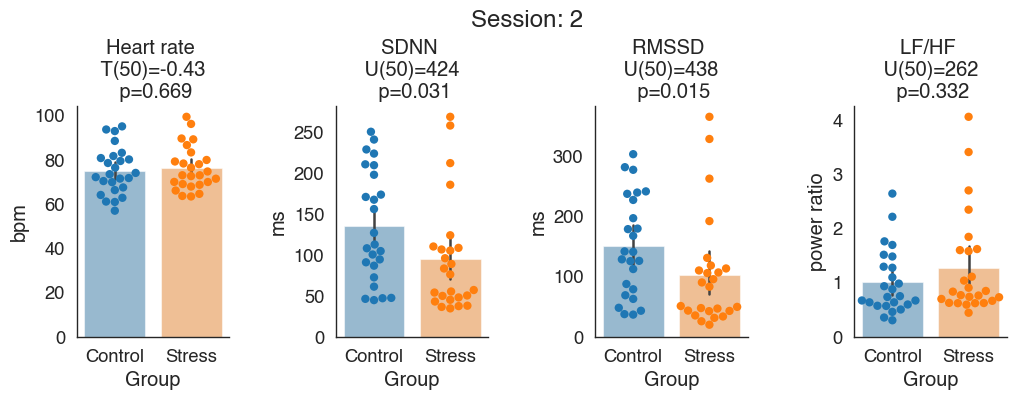

In [12]:
ses=2
tmp = df.groupby(['subject','session','Group']).mean().xs(ses,0,level='session')
tmp = tmp.reset_index()
tmp['Group'] = np.where(tmp['Group'] == 0, 'Control', 'Stress')
tmp.set_index(['subject','Group'], inplace=True)


fig, axs = plt.subplots(1,len(varlist), figsize=(len(varlist) * 3,3))
for i, y_var in enumerate(varlist):
    sns.barplot(data=tmp.reset_index(), x ='Group', hue='Group', y=y_var, alpha=0.5,ax=axs[i]) #legend=False, 
    sns.swarmplot(data=tmp.reset_index(), x='Group', hue='Group', y=y_var, size=6, ax=axs[i],legend=False, )
    
    # test if data is normally distributed and perform t-test or mannwhitneyu test
    _, pval_normal = normaltest(tmp[y_var])
    if pval_normal > alpha:
        print(f'{y_var} - normal distribution (fail to reject H0)')
        stats = ttest_ind(tmp.xs('Control',0,'Group')[y_var], tmp.xs('Stress',0,'Group')[y_var], axis=0, equal_var=False)
        stat_coef = f'T(50)={np.round(stats.statistic,2)}'
    else: # non parametric test
        print(f'{y_var} - not normal distribution (reject H0)')        
        stats = mannwhitneyu(tmp.xs('Control',0,'Group')[y_var], tmp.xs('Stress',0,'Group')[y_var], axis=0)
        stat_coef = f'U(50)={int(stats.statistic)}'

    p_val = np.round(stats.pvalue,3)
    axs[i].set(title=f'{name_list[i]} \n {stat_coef} \n p={p_val}', ylabel=unit_list[i], xlabel='Group')
    sns.despine()
    print(stats)
    
fig.suptitle(f'Session: {ses}', y=1.2)
fig.subplots_adjust(wspace=0.7) 
plt.savefig(op.join(supplements_path, f'HRV_group_diffs_session-{ses}.png'), dpi=300, bbox_inches='tight')

In [8]:
stats.statistic

262.0

HR_bpm - normal distribution (fail to reject H0)
Ttest_indResult(statistic=-1.7558429743546138, pvalue=0.08555571807935063)
HRV_SDNN - normal distribution (fail to reject H0)
Ttest_indResult(statistic=1.4789662040936942, pvalue=0.14657790414169775)
HRV_RMSSD - normal distribution (fail to reject H0)
Ttest_indResult(statistic=1.4665664100876918, pvalue=0.14943100288193575)
HRV_LFHF - not normal distribution (reject H0)
MannwhitneyuResult(statistic=203.0, pvalue=0.03443756329229049)


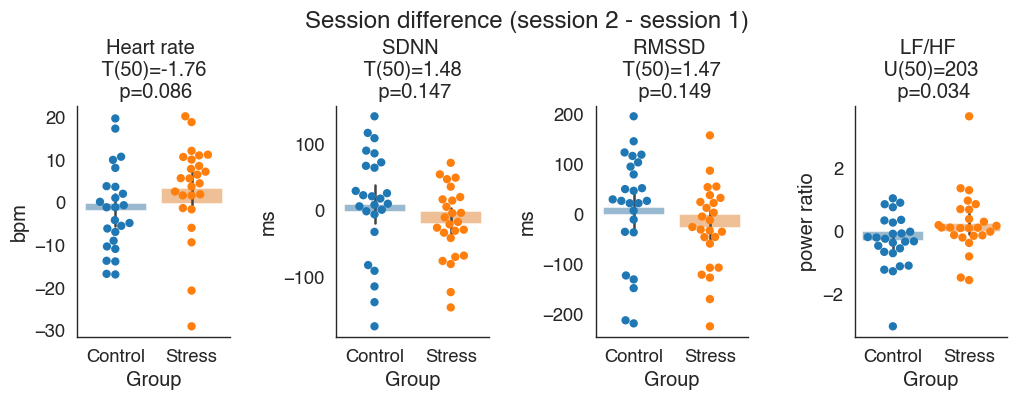

In [13]:

ses = 'Session difference (session 2 - session 1)'
tmp = df.groupby(['subject','session','Group']).mean().xs(2,0,level='session') - df.groupby(['subject','session','Group']).mean().xs(1,0,level='session')

tmp = tmp.reset_index()
tmp['Group'] = np.where(tmp['Group'] == 0, 'Control', 'Stress')
tmp.set_index(['subject','Group'], inplace=True)

fig, axs = plt.subplots(1,len(varlist), figsize=(len(varlist) * 3,3))
for i, y_var in enumerate(varlist):
    sns.barplot(data=tmp.reset_index(), x ='Group', hue='Group', y=y_var, alpha=0.5,ax=axs[i]) #legend=False, 
    sns.swarmplot(data=tmp.reset_index(), x='Group', hue='Group', y=y_var, size=6, ax=axs[i],legend=False, )
    
    # test if data is normally distributed and perform t-test or mannwhitneyu test
    _, pval_normal = normaltest(tmp[y_var])
    if pval_normal > alpha:
        print(f'{y_var} - normal distribution (fail to reject H0)')
        stats = ttest_ind(tmp.xs('Control',0,'Group')[y_var], tmp.xs('Stress',0,'Group')[y_var], axis=0, equal_var=False)
        stat_coef = f'T(50)={np.round(stats.statistic,2)}'
    else: # non parametric test
        print(f'{y_var} - not normal distribution (reject H0)')        
        stats = mannwhitneyu(tmp.xs('Control',0,'Group')[y_var], tmp.xs('Stress',0,'Group')[y_var], axis=0)
        stat_coef = f'U(50)={int(stats.statistic)}'

    p_val = np.round(stats.pvalue,3)
    axs[i].set(title=f'{name_list[i]} \n {stat_coef} \n p={p_val}', ylabel=unit_list[i], xlabel='Group')
    sns.despine()
    print(stats)


fig.suptitle(f'{ses}', y=1.2)
fig.subplots_adjust(wspace=0.7) 
#plt.savefig(op.join(supplements_path, f'HRV_group_diffs_session-diff.png'), dpi=300, bbox_inches='tight')

In [20]:
from scipy.stats import normaltest # from scipy.stats import shapiro # same results for shapiro test! 


for y_var in [ 'HR_bpm','HRV_SDNN', 'HRV_RMSSD', 'HRV_LFHF']:
    for group in ['Control', 'Stress']:
        data = tmp[y_var]

        # Perform the normaltest
        statistic, p_value = normaltest(data)
        alpha = 0.05
        print(f'group {group}, {y_var}:')
        print("The data follows a normal distribution (fail to reject H0).") if p_value > alpha else print("The data does not follow a normal distribution (reject H0).")


group Control, HR_bpm:
The data follows a normal distribution (fail to reject H0).
group Stress, HR_bpm:
The data follows a normal distribution (fail to reject H0).
group Control, HRV_SDNN:
The data follows a normal distribution (fail to reject H0).
group Stress, HRV_SDNN:
The data follows a normal distribution (fail to reject H0).
group Control, HRV_RMSSD:
The data follows a normal distribution (fail to reject H0).
group Stress, HRV_RMSSD:
The data follows a normal distribution (fail to reject H0).
group Control, HRV_LFHF:
The data does not follow a normal distribution (reject H0).
group Stress, HRV_LFHF:
The data does not follow a normal distribution (reject H0).
